In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm
import xarray as xr
import mne

In [25]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
try:
    mne.viz.set_3d_backend('notebook')
except Exception:
    mne.viz.set_3d_backend('pyvista')
# text svg

In [26]:
# Shared constants
from pathlib import Path
from mne_bids import BIDSPath
from tqdm import tqdm
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
from scipy.spatial import cKDTree
from matplotlib.colors import ListedColormap
import matplotlib.colors as mcolors
import pyvista as pv
from mne.viz import Brain

GRANTFIG_DIR = Path('grantfig')
GRANTFIG_DIR.mkdir(exist_ok=True)

PHASES = ['stimulus', 'delay', 'go', 'response']
XCORR_TASKS = ['LexicalDelay', 'PhonemeSequence']
XCORR_REF = 'bipolar'
MIN_PEAK_VAL = 0.01
MAX_ABS_LAG_S = 0.5
EXCLUDE_ROIS = {'Intersection', 'LinG', 'OccS', 'CollatAnt', 'Central', 'PIC'}
ROI_MAP = {'MFGs': 'MFG', 'IFGs': 'IFG', 'SFGs': 'SFG', 'OFCs': 'OFC'}

PARTNER2COLOR = {
    'IFG': '#f3eed9', 'MFG': '#f3eed9', 'OFC': '#f3eed9', 'SFG': '#f3eed9',
    'SMC': '#ababab', 'STG': '#1A1A1A', 'STS': '#1A1A1A', 'Thal': '#2C8DA8',
    'dACC': '#6FB3C8', 'AIC': red, 'PIC': blue,
}
FALLBACK_COLOR = '#bdbdbd'

ROI_GROUPS = {
    'Frontal': ['IFG', 'MFG', 'SFG', 'OFC'],
    'SMC': ['SMC'],
}

GROUPED_LAG_SPECS = [
    dict(partner_group='Frontal', partner_rois=ROI_GROUPS['Frontal'], phases=['stimulus', 'delay'],
         savepath='aim3_explore_lagstrip_AIC_Frontal_stim_delay.svg'),
    dict(partner_group='SMC', partner_rois=ROI_GROUPS['SMC'], phases=['delay', 'go'],
         savepath='aim3_explore_lagstrip_AIC_SMC_delay_go.svg'),
]


## Load HGAs + xcorr data

In [18]:
# --- HGAs ---
hga_tasks = ['PhonemeSequence', 'LexicalNoDelay', 'LexicalDelay']
hga_paths = []
for t in hga_tasks:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({XCORR_REF})',
            datatype='HGA', suffix='time', check=False,
        ).match()
    )

HGAs = pd.concat([pd.read_csv(p) for p in tqdm(hga_paths, desc='HGAs')])
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'
HGAs['phase'] = HGAs['phase'].str.lower()
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post', 'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal']), 'roi'] = 'PCC'
HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Ant', 'ctx_rh_G_and_S_cingul-Mid-Ant']), 'roi'] = 'dACC'
HGAs.loc[HGAs.roi == 'CG', 'roi'] = 'ACC'

exclude_df = pd.read_csv('../results/exlude_insula.csv', index_col=0)
exclude_chn = [
    electrode for item in exclude_df.Exclude.dropna()
    for electrode in eval(item)
]
HGAs = HGAs[~HGAs.channel.isin(exclude_chn)].copy()

def classify_insula_row(row, y_threshold=0):
    if row['roi'] != 'Insula':
        return row['roi']
    label, y_coord = row['label'], row['y']
    if ('G_insular_short' in label or 'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    if ('G_Ins_lg_and_S_cent_ins' in label or
        ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
        ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    return row['roi']

HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)
print(f'AIC electrodes: {(HGAs.roi == "AIC").sum()} | PIC: {(HGAs.roi == "PIC").sum()}')

# --- xcorr clusters ---
all_clusters = []
for task_name in XCORR_TASKS:
    results_root = f'../results/{task_name}({XCORR_REF})'
    base = BIDSPath(
        root=results_root, datatype='xcorr', task=task_name,
        recording='highgamma', description='Repeat', suffix='perm', check=False,
    )
    csv_paths = base.copy().update(extension='.csv').match()
    print(f'[{task_name}] csv={len(csv_paths)}')
    for p in csv_paths:
        df = pd.read_csv(p.fpath)
        df['task'] = task_name
        df['phase'] = p.processing
        df['description'] = p.description
        df['file'] = str(p.fpath)
        all_clusters.append(df)

clusters_df = pd.concat(all_clusters, ignore_index=True)
print('Total cluster rows:', len(clusters_df))

channel_meta = (
    HGAs[['channel', 'roi', 'hemi']].dropna()
    .groupby(['channel', 'roi', 'hemi'], as_index=False).size()
    .sort_values(['channel', 'size'], ascending=[True, False])
    .drop_duplicates('channel').drop(columns='size')
)

sig_roi_df = (
    clusters_df.loc[clusters_df['significant'] == True].copy()
    .merge(channel_meta.rename(columns={'channel': 'source_channel', 'roi': 'source_roi', 'hemi': 'source_hemi'}),
           on='source_channel', how='left')
    .merge(channel_meta.rename(columns={'channel': 'target_channel', 'roi': 'target_roi', 'hemi': 'target_hemi'}),
           on='target_channel', how='left')
)
print('sig rows:', len(sig_roi_df))

ds_cache = {}

def get_ds(nc_file):
    if nc_file not in ds_cache:
        ds_cache[nc_file] = xr.load_dataset(nc_file)
    return ds_cache[nc_file]

peak_rows = []
sig = sig_roi_df.copy()
sig['nc_file'] = sig['file'].apply(lambda x: str(Path(x).with_suffix('.nc')))

for _, row in tqdm(sig.iterrows(), total=len(sig), desc='peaks'):
    nc_file = row['nc_file']
    pair_idx = int(row['pair_idx'])
    lag_start, lag_end = float(row['lag_start_s']), float(row['lag_end_s'])
    ds = get_ds(nc_file)
    if pair_idx < 0 or pair_idx >= ds.sizes['pair']:
        continue
    obs = ds['observed_curve'].isel(pair=pair_idx).values
    nul = ds['null_mean'].isel(pair=pair_idx).values
    lag = ds['lag'].values
    mask = (lag >= lag_start) & (lag <= lag_end)
    if not mask.any() or not np.isfinite(obs[mask]).any():
        continue
    obs_in_cluster = obs[mask]
    lag_in_cluster = lag[mask]
    peak_idx_local = np.nanargmax(obs_in_cluster)
    peak_lag = float(lag_in_cluster[peak_idx_local])
    peak_val = float(obs_in_cluster[peak_idx_local])
    peak_idx_global = int(np.argmin(np.abs(lag - peak_lag)))
    null_at_peak = float(nul[peak_idx_global])
    peak_rows.append({
        'pair_idx': pair_idx,
        'source_channel': row['source_channel'], 'target_channel': row['target_channel'],
        'source_roi': row.get('source_roi'), 'target_roi': row.get('target_roi'),
        'source_hemi': row.get('source_hemi'), 'target_hemi': row.get('target_hemi'),
        'peak_lag_s': peak_lag, 'peak_val': peak_val,
        'peak_excess': peak_val - null_at_peak,
        'task': row.get('task'), 'phase': row.get('phase'), 'description': row.get('description'),
        'file': row['file'],
    })

peaks_df_raw = pd.DataFrame(peak_rows)
peaks_df = peaks_df_raw[
    (peaks_df_raw['peak_val'] >= MIN_PEAK_VAL) &
    (peaks_df_raw['peak_lag_s'].abs() <= MAX_ABS_LAG_S)
].copy()
print(f'peaks_df: {len(peaks_df)} (raw {len(peaks_df_raw)})')
peaks_df.head()


HGAs: 100%|██████████| 915/915 [00:40<00:00, 22.62it/s]


AIC electrodes: 236800 | PIC: 203200
[LexicalDelay] csv=175
[PhonemeSequence] csv=177
Total cluster rows: 12073
sig rows: 12073


peaks: 100%|██████████| 12073/12073 [00:28<00:00, 419.26it/s]


peaks_df: 12027 (raw 12073)


,pair_idx,source_channel,target_channel,source_roi,target_roi,source_hemi,target_hemi,peak_lag_s,peak_val,peak_excess,task,phase,description,file
0,1,D0023_RPIF2-3,D0023_RPIF4-5,Sylvian,Intersection,R,R,0.000000,0.084855,0.020654,LexicalDelay,Delay,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
1,26,D0023_R2IF4-5,D0023_R1MF12-13,Intersection,Intersection,R,R,0.296875,0.050224,0.012632,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
2,28,D0023_R2IF4-5,D0023_R2MF1-2,Intersection,dACC,R,R,-0.015625,0.059117,0.011012,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
3,44,D0023_RPSF1-2,D0023_RPIF8-9,CGs,AG,R,R,-0.015625,0.084576,0.017216,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...
4,59,D0023_RPSF1-2,D0023_RPMF11-12,CGs,Intersection,R,R,-0.085938,0.070740,0.016854,LexicalDelay,Go,Repeat,../results/LexicalDelay(bipolar)/sub-D0023/xco...


## Connectivity plot helpers

In [30]:
def _normalize_peaks(peaks_df):
    df = peaks_df.copy()
    df['source_roi'] = df['source_roi'].replace(ROI_MAP)
    df['target_roi'] = df['target_roi'].replace(ROI_MAP)
    df['phase_norm'] = df['phase'].astype(str).str.lower().str.strip()
    return df


def prepare_lag_agg(
    peaks_df, phase_keep, focus_roi,
    partner_keep=None, partner_group=None, top_k=6, min_lag_ms=5, max_abs_lag_ms=500,
):
    phases = [phase_keep] if isinstance(phase_keep, str) else list(phase_keep)
    df = _normalize_peaks(peaks_df)
    df = df[
        (~df['source_roi'].isin(EXCLUDE_ROIS)) &
        (~df['target_roi'].isin(EXCLUDE_ROIS)) &
        (df['phase_norm'].isin(phases))
    ].copy()
    mask = (df['source_roi'] == focus_roi) | (df['target_roi'] == focus_roi)
    df = df[mask].copy()
    df = df[~((df['source_roi'] == focus_roi) & (df['target_roi'] == focus_roi))].copy()
    if df.empty:
        return None
    df['partner_roi'] = np.where(df['source_roi'] == focus_roi, df['target_roi'], df['source_roi'])
    df['lag_focus_leads'] = np.where(df['source_roi'] == focus_roi, df['peak_lag_s'], -df['peak_lag_s'])
    df = df[df['lag_focus_leads'].abs() <= max_abs_lag_ms / 1000].copy()
    if partner_keep is not None:
        df = df[df['partner_roi'].isin(partner_keep)].copy()
    if partner_group is not None:
        df['partner_roi'] = partner_group
    if df.empty:
        return None
    df['subject'] = df['source_channel'].str.extract(r'^(D\d+)_')[0]
    ab = np.sort(df[['source_channel', 'target_channel']].values, axis=1)
    df['pair_key'] = ab[:, 0] + '||' + ab[:, 1]
    agg = (
        df.groupby(['partner_roi', 'pair_key', 'subject'], as_index=False)
          .agg(lag_focus_leads=('lag_focus_leads', 'mean'))
    )
    agg = agg[agg['lag_focus_leads'].abs() >= min_lag_ms / 1000].copy()
    if partner_group is None:
        if partner_keep is not None:
            agg = agg[agg['partner_roi'].isin(partner_keep)].copy()
        elif top_k is not None:
            partner_counts = agg.groupby('partner_roi').size().sort_values(ascending=False)
            top_partners = partner_counts.head(top_k).index.tolist()
            agg = agg[agg['partner_roi'].isin(top_partners)].copy()
    if agg.empty:
        return None
    partner_order = (
        agg.groupby('partner_roi')['lag_focus_leads'].median().sort_values().index.tolist()
    )
    return {'agg': agg, 'partner_order': partner_order, 'subjects': sorted(agg['subject'].dropna().unique())}


def _format_phase_label(phase_keep):
    if isinstance(phase_keep, str):
        return phase_keep.capitalize()
    return ' + '.join(p.capitalize() for p in phase_keep)


def plot_lag_strip(
    peaks_df, phase_keep, focus_roi,
    partner_keep=None, partner_group=None, top_k=6, min_lag_ms=5, max_abs_lag_ms=500,
    savepath=None, show_title=True,
):
    prepared = prepare_lag_agg(
        peaks_df, phase_keep, focus_roi,
        partner_keep=partner_keep, partner_group=partner_group, top_k=top_k,
        min_lag_ms=min_lag_ms, max_abs_lag_ms=max_abs_lag_ms,
    )
    if prepared is None:
        print(f'SKIP lag strip: no data for {focus_roi} / {phase_keep}')
        return None
    agg = prepared['agg']
    partner_order = prepared['partner_order']
    subjects = prepared['subjects']
    partner_to_y = {p: i for i, p in enumerate(partner_order)}

    row_h = 0.7 if len(partner_order) > 1 else 2.0
    fig, ax = plt.subplots(figsize=(4 * cm, (row_h * len(partner_order) + 1) * cm))
    cmap = plt.colormaps.get_cmap('tab10').resampled(max(len(subjects), 1))
    sub_to_color = {s: cmap(i) for i, s in enumerate(subjects)}

    for _, row in agg.iterrows():
        y = partner_to_y[row['partner_roi']]
        ax.vlines(
            row['lag_focus_leads'] * 1000, y - 0.15, y + 0.15,
            colors=sub_to_color[row['subject']], linewidths=1.2, alpha=0.7,
        )

    sub_center = (
        agg.groupby(['partner_roi', 'subject'], as_index=False)
           .agg(sub_lag=('lag_focus_leads', 'median'))
    )
    center_df = sub_center.groupby('partner_roi', as_index=False).agg(center_lag=('sub_lag', 'mean'))
    for _, r in center_df.iterrows():
        if r['partner_roi'] not in partner_to_y:
            continue
        ax.scatter(
            r['center_lag'] * 1000, partner_to_y[r['partner_roi']],
            s=10, marker='o', facecolor='None', edgecolor='black', linewidth=1, zorder=6,
        )

    ax.axvline(0, color='k', ls='--', lw=1, alpha=0.6)
    ax.set_yticks(range(len(partner_order)))
    ax.set_yticklabels(partner_order, fontsize=fontsize)
    ax.set_xlabel('Lag (ms)', fontsize=fontsize)
    ax.set_xlim(-500, 500)
    ax.set_ylim(-0.5, len(partner_order) - 0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
    sns.despine(ax=ax, offset=1, trim=True, left=True)
    ax.tick_params(left=False)

    for partner in partner_order:
        n = len(agg[agg['partner_roi'] == partner])
        ax.text(700, partner_to_y[partner], f'n={n}', ha='right', va='center', fontsize=fontsize, color='#666')

    if show_title:
        phase_label = _format_phase_label(phase_keep)
        if partner_group is not None:
            title_line1 = f'{focus_roi} lag | {partner_group} ({phase_label})'
        else:
            title_line1 = f'{focus_roi} lag | {phase_label}'
        ax.set_title(
            f'{title_line1}\n'
            f'← {focus_roi} leads | {focus_roi} lags →',
            fontsize=fontsize + 1, fontweight='bold',
        )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'saved {savepath} | partners={partner_order} | n={len(agg)}')
    return fig


def plot_partner_count_bar(
    peaks_df, phases=None, focus_rois=None, top_k=7,
    savepath=None,
):
    phases = phases or PHASES
    focus_rois = focus_rois or ['AIC']
    df = _normalize_peaks(peaks_df)
    df = df[df['peak_lag_s'].abs() <= 0.5].copy()
    df = df.dropna(subset=['source_roi', 'target_roi', 'source_channel', 'target_channel', 'phase_norm'])
    df = df[
        (~df['source_roi'].isin(EXCLUDE_ROIS)) &
        (~df['target_roi'].isin(EXCLUDE_ROIS)) &
        (df['phase_norm'].isin(phases))
    ].copy()
    ab = np.sort(df[['source_channel', 'target_channel']].values, axis=1)
    df['pair_key'] = ab[:, 0] + '||' + ab[:, 1]
    rows = []
    for focus in focus_rois:
        tmp = df[(df['source_roi'] == focus) | (df['target_roi'] == focus)].copy()
        tmp = tmp[~((tmp['source_roi'] == focus) & (tmp['target_roi'] == focus))].copy()
        if tmp.empty:
            continue
        tmp['focus_roi'] = focus
        tmp['partner_roi'] = np.where(tmp['source_roi'] == focus, tmp['target_roi'], tmp['source_roi'])
        rows.append(tmp[['phase_norm', 'focus_roi', 'partner_roi', 'pair_key']])
    if not rows:
        print('SKIP partner count bar: no data')
        return None
    long_df = pd.concat(rows, ignore_index=True)
    agg = long_df.groupby(['phase_norm', 'focus_roi', 'partner_roi'], as_index=False).agg(n_pairs=('pair_key', 'nunique'))
    top_chunks = []
    for ph in phases:
        for focus in focus_rois:
            sub = agg[(agg['phase_norm'] == ph) & (agg['focus_roi'] == focus)].copy()
            if sub.empty:
                continue
            top_chunks.append(sub.sort_values('n_pairs', ascending=False).head(top_k))
    top_df = pd.concat(top_chunks, ignore_index=True)
    partners = sorted(top_df['partner_roi'].unique())
    partner2color = PARTNER2COLOR.copy()
    for p in partners:
        partner2color.setdefault(p, FALLBACK_COLOR)

    sns.set_theme(style='white')
    fig, axes = plt.subplots(1, len(phases), figsize=(3.6 * len(phases) * cm, 6.8 * cm), sharey=True)
    if len(phases) == 1:
        axes = [axes]
    for ax, ph in zip(axes, phases):
        x_pos = np.arange(len(focus_rois))
        bar_width = 0.36
        totals = []
        for i, focus in enumerate(focus_rois):
            sub = top_df[(top_df['phase_norm'] == ph) & (top_df['focus_roi'] == focus)].copy()
            bottom = 0
            if sub.empty:
                totals.append(0)
                continue
            for _, r in sub.sort_values('n_pairs', ascending=False).iterrows():
                v, p = r['n_pairs'], r['partner_roi']
                ax.bar(x_pos[i], v, width=bar_width, bottom=bottom,
                       color=partner2color[p], edgecolor='white', linewidth=0.9)
                if v >= 2:
                    t = ax.text(x_pos[i], bottom + v / 2, p, ha='center', va='center', fontsize=6, color='black')
                    t.set_path_effects([pe.withStroke(linewidth=2, foreground='white', alpha=0.95)])
                bottom += v
            totals.append(bottom)
        ax.set_title(ph.capitalize(), fontsize=fontsize + 1)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(focus_rois, fontsize=fontsize)
        for i, t in enumerate(totals):
            ax.text(x_pos[i], t + 2.5, f'{int(t)}', ha='center', va='bottom', fontsize=fontsize, fontweight='bold')
        sns.despine(ax=ax, offset=2, trim=True)
    axes[0].set_ylabel('# significant pairs', fontsize=fontsize + 1)
    fig.suptitle('AIC partner composition (top partners, PIC excluded)', fontsize=fontsize + 2, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 0.95, 0.94])
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'saved {savepath}')
    return fig


def plot_connectivity_brain(
    sig_roi_df, HGAs, phase_keep='stimulus', phases=None, focus_roi='AIC',
    exclude_channels=None, savepath=None, bandwidth=8.0,
):
    exclude_channels = exclude_channels or exclude_chn
    if phases is not None:
        phase_list = [p.lower() for p in phases]
        phase_title = 'All phases'
    elif phase_keep in (None, 'all'):
        phase_list = [p.lower() for p in PHASES]
        phase_title = 'All phases'
    else:
        phase_list = [phase_keep.lower()]
        phase_title = f'{phase_keep.capitalize()}-phase'

    phase_norm = sig_roi_df['phase'].astype(str).str.lower().str.strip()
    phase_mask = phase_norm.isin(phase_list)
    phase_df = sig_roi_df[
        phase_mask & sig_roi_df['source_roi'].notna() & sig_roi_df['target_roi'].notna()
    ].copy()
    phase_df = phase_df[
        (~phase_df['source_roi'].isin(EXCLUDE_ROIS)) &
        (~phase_df['target_roi'].isin(EXCLUDE_ROIS))
    ].copy()
    src_is = phase_df['source_roi'] == focus_roi
    tgt_is = phase_df['target_roi'] == focus_roi
    phase_df = phase_df[src_is ^ tgt_is].copy()
    if phase_df.empty:
        print(f'SKIP brain map: no data for {focus_roi} / {phase_list}')
        return None
    phase_df['focus_channel'] = np.where(phase_df['source_roi'] == focus_roi, phase_df['source_channel'], phase_df['target_channel'])
    phase_df['partner_channel'] = np.where(phase_df['source_roi'] == focus_roi, phase_df['target_channel'], phase_df['source_channel'])
    focus_channels = set(phase_df['focus_channel']) - set(exclude_channels)
    partner_channels = set(phase_df['partner_channel']) - set(exclude_channels)

    coord_lookup = HGAs[['channel', 'x', 'y', 'z']].dropna().groupby('channel', as_index=False).first().set_index('channel')
    focus_coords = coord_lookup.loc[[c for c in focus_channels if c in coord_lookup.index]][['x', 'y', 'z']].values
    partner_coords = coord_lookup.loc[[c for c in partner_channels if c in coord_lookup.index]][['x', 'y', 'z']].values

    lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
    rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial')
    lh_tree = cKDTree(lh_pial_coords)
    rh_tree = cKDTree(rh_pial_coords)
    max_distance = 15.0

    def compute_density(surface_coords, electrode_coords, bw, max_dist):
        if len(electrode_coords) == 0:
            return np.zeros(len(surface_coords)), np.zeros(len(surface_coords), dtype=bool)
        distances = cdist(surface_coords, electrode_coords)
        mask = distances.min(axis=1) < max_dist
        kernel = np.exp(-distances ** 2 / (2 * bw ** 2))
        density = kernel.sum(axis=1)
        density[~mask] = 0
        return density, mask

    def add_electrodes(brain, coords, tree, surf_coords, color, size=14, opacity=1.0):
        if len(coords) == 0:
            return
        _, idx = tree.query(coords)
        cloud = pv.PolyData(surf_coords[idx])
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True, point_size=size,
            color=color, lighting=False, smooth_shading=False, opacity=opacity,
        )

    mask_focus_lh = focus_coords[:, 0] < 0 if len(focus_coords) else np.array([], dtype=bool)
    mask_focus_rh = focus_coords[:, 0] > 0 if len(focus_coords) else np.array([], dtype=bool)
    mask_par_lh = partner_coords[:, 0] < 0 if len(partner_coords) else np.array([], dtype=bool)
    mask_par_rh = partner_coords[:, 0] > 0 if len(partner_coords) else np.array([], dtype=bool)
    lh_density, lh_dmask = compute_density(lh_pial_coords, partner_coords[mask_par_lh], bandwidth, max_distance)
    rh_density, rh_dmask = compute_density(rh_pial_coords, partner_coords[mask_par_rh], bandwidth, max_distance)
    all_valid = np.concatenate([lh_density[lh_dmask & (lh_density > 0)], rh_density[rh_dmask & (rh_density > 0)]])
    vmin_d, vmax_d = (float(np.percentile(all_valid, 10)), float(np.percentile(all_valid, 80))) if len(all_valid) else (0.0, 1.0)
    n_colors = 256
    base_rgb = np.array(mcolors.to_rgb(blue))
    colors_list = [[1, 1, 1, 0]]
    for i in range(1, n_colors):
        t = i / (n_colors - 1)
        rgb = (1 - t) * np.array([1, 1, 1]) + t * base_rgb
        colors_list.append(list(rgb) + [0.9])
    density_cmap = ListedColormap(colors_list)

    def render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h):
        brain = Brain('cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial', hemi=hemi,
                      background='white', show=False, cortex=(0.9, 0.9, 0.9), alpha=0.9, size=(800, 800))
        data = np.zeros(len(surf_coords))
        has_data = dmask & (density > 0)
        if has_data.any():
            norm = np.clip((density[has_data] - vmin_d) / (vmax_d - vmin_d + 1e-12), 0, 1)
            data[has_data] = 1 + norm * (n_colors - 2)
        brain.add_data(data, hemi=hemi, colormap=density_cmap, alpha=1.0, colorbar=False, fmin=0, fmax=n_colors - 1)
        if focus_mask_h.any():
            add_electrodes(brain, focus_coords[focus_mask_h], tree, surf_coords, color=red, size=14, opacity=1.0)
        brain.show_view(view=view, distance=400)
        return brain

    panels = [
        ('lh', 'lateral', lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, 'Left — Lateral'),
        ('rh', 'lateral', rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, 'Right — Lateral'),
        ('lh', 'medial', lh_density, lh_dmask, lh_pial_coords, lh_tree, mask_focus_lh, 'Left — Medial'),
        ('rh', 'medial', rh_density, rh_dmask, rh_pial_coords, rh_tree, mask_focus_rh, 'Right — Medial'),
    ]
    screenshots, brains = [], []
    for hemi, view, density, dmask, surf_coords, tree, focus_mask_h, title in panels:
        b = render_brain(hemi, view, density, dmask, surf_coords, tree, focus_mask_h)
        screenshots.append((b.screenshot(mode='rgb'), title))
        brains.append(b)
    fig, axes = plt.subplots(2, 2, figsize=(16 * cm, 16 * cm))
    for ax, (img, title) in zip(axes.flat, screenshots):
        ax.imshow(img); ax.axis('off'); ax.set_title(title, fontsize=fontsize)
    legend_elements = [
        Patch(facecolor=red, label=f'{focus_roi} (n={len(focus_channels)})'),
        Patch(facecolor=blue, label=f'Partner (n={len(partner_channels)})'),
    ]
    axes[0, 0].legend(handles=legend_elements, loc='upper left', fontsize=fontsize - 1, framealpha=0.9)
    fig.suptitle(f'{phase_keep.capitalize()}-phase {focus_roi} connectivity', fontsize=fontsize + 1)
    for b in brains:
        b.close()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
        print(f'saved {savepath} | focus={len(focus_channels)} partner={len(partner_channels)}')
    return fig


## Batch A — AIC ↔ SMC lag strips (all phases)

saved grantfig/aim3_explore_AIC_focus_SMC_stimulus.svg | partners=['SMC'] | n=2
saved grantfig/aim3_explore_AIC_focus_SMC_delay.svg | partners=['SMC'] | n=3
saved grantfig/aim3_explore_AIC_focus_SMC_go.svg | partners=['SMC'] | n=10
saved grantfig/aim3_explore_AIC_focus_SMC_response.svg | partners=['SMC'] | n=12


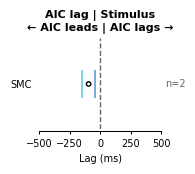

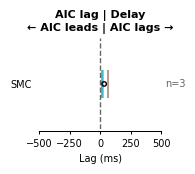

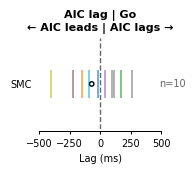

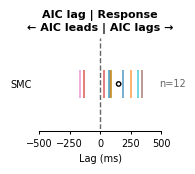

In [20]:
batch_a_specs = [
    ('AIC', ['SMC'], 'aim3_explore_AIC_focus_SMC_{phase}.svg'),
]
for phase in PHASES:
    for focus_roi, partner_keep, fname_tpl in batch_a_specs:
        plot_lag_strip(
            peaks_df, phase, focus_roi,
            partner_keep=partner_keep, top_k=None,
            savepath=GRANTFIG_DIR / fname_tpl.format(phase=phase),
        )


## Batch B — grouped lag strips (Frontal–AIC, SMC–AIC)

Per-phase AIC top-partner strips are kept below as commented reference.

saved grantfig/aim3_explore_lagstrip_AIC_Frontal_stim_delay.svg | partners=['Frontal'] | n=40
saved grantfig/aim3_explore_lagstrip_AIC_SMC_delay_go.svg | partners=['SMC'] | n=13


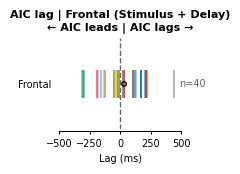

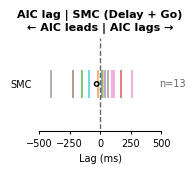

In [21]:
for spec in GROUPED_LAG_SPECS:
    plot_lag_strip(
        peaks_df,
        phase_keep=spec['phases'],
        focus_roi='AIC',
        partner_keep=spec['partner_rois'],
        partner_group=spec['partner_group'],
        top_k=None,
        savepath=GRANTFIG_DIR / spec['savepath'],
    )

# Per-phase AIC top-6 reference (uncomment to regenerate)
# for focus_roi in ['AIC']:
#     for phase in PHASES:
#         plot_lag_strip(
#             peaks_df, phase, focus_roi,
#             top_k=6, partner_keep=None,
#             savepath=GRANTFIG_DIR / f'aim3_explore_lagstrip_{focus_roi}_{phase}.svg',
#         )


## Supplementary — partner count bar + brain maps (stimulus & delay)

## Aim 3.3 — Cross-Regional Window Decoding (CCA)

Train `AICl`, test partner ROIs. **Four phase panels** (Stimulus / Delay / Go / Response) with SEM error bars. Results: `results/{Task}(cross_roi)(bipolar)/sub-AICl2{partner}/(cross)(window){datatype}/`.

In [39]:
REF = 'bipolar'
TRAIN_ROI = 'AICl'
PARTNER_ROIS = ['STG', 'IFG', 'MFG', 'SMC']
PARTNER_BIDS = {
    'IFG': 'IFGl', 'STG': 'STGl', 'STS': 'STSl', 'MFG': 'MFGl',
    'SMC': 'SMCl',
}
PHASES_GRANT = ['Stimulus', 'Delay', 'Go', 'Response']
CHANCE = {'lexicality': 0.5, 'articulator': 0.25}

PARTNER_COLORS = {p: PARTNER2COLOR.get(p, FALLBACK_COLOR) for p in PARTNER_ROIS}


def _partners_for_plot(df, phase='Delay'):
    return list(PARTNER_ROIS)


def _partner_label(test_roi_bids):
    for label, bids in PARTNER_BIDS.items():
        if bids == test_roi_bids:
            return label
    return test_roi_bids.replace('l', '')


def load_cross_roi_window(task, datatype, description='Repeat'):
    root = Path(f'../results/{task}(cross_roi)({REF})')
    rows = []
    for partner_dir in sorted(root.glob('sub-AICl2*')):
        test_bids = partner_dir.name.replace('sub-AICl2', '')
        partner = _partner_label(test_bids)
        dtype_dir = partner_dir / f'(cross)(window){datatype}'
        if not dtype_dir.is_dir():
            continue
        for h5 in dtype_dir.glob('*.h5'):
            with h5py.File(h5, 'r') as f:
                scores = np.asarray(f['scores'][()], dtype=float)
                pval = float(f['p_value'][()])
            if not np.isfinite(scores).all() or scores.max() > 1.5 or scores.min() < -0.5:
                print(f'SKIP bad scores: {h5}')
                continue
            phase = h5.name.split('_proc-')[1].split('_desc-')[0]
            n_folds = len(scores)
            sem = float(np.std(scores, ddof=1) / np.sqrt(n_folds)) if n_folds > 1 else 0.0
            rows.append({
                'task': task,
                'datatype': datatype,
                'partner': partner,
                'phase': phase,
                'accuracy': float(scores.mean()),
                'sem': sem,
                'p_value': pval,
                'n_folds': n_folds,
            })
    df = pd.DataFrame(rows)
    if df.empty:
        print(f'No cross_roi window results for {task} / {datatype}')
    return df


def _plot_cross_roi_phase_ax(ax, sub, datatype, partners, sig_p=0.05):
    chance = CHANCE[datatype]
    x = np.arange(len(partners))
    accs, sems, colors = [], [], []
    for i, partner in enumerate(partners):
        row = sub[sub.partner == partner]
        if row.empty:
            accs.append(np.nan)
            sems.append(0.0)
            colors.append('#dddddd')
        else:
            acc = row.accuracy.values[0]
            sem = row['sem'].values[0]
            accs.append(acc)
            sems.append(sem)
            colors.append(PARTNER_COLORS.get(partner, FALLBACK_COLOR))
            if row.p_value.values[0] < sig_p:
                ax.plot(i, acc + sem + 0.02, '*', color=red, ms=5, clip_on=False)
    ax.bar(
        x, accs, yerr=sems, color=colors, edgecolor='white', linewidth=0.6, width=0.7,
        error_kw=dict(ecolor='black', elinewidth=0.75, capsize=2, capthick=0.75),
    )
    ax.axhline(chance, color='gray', ls='--', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(partners, fontsize=fontsize)
    ax.set_xlim(-0.6, len(partners) - 0.4)
    ax.tick_params(labelsize=fontsize)


def plot_cross_roi_window_panel(df, datatype, title, save_path=None, sig_p=0.05, phases=None):
    if df.empty:
        return None
    phases = phases or PHASES_GRANT
    partners = _partners_for_plot(df)
    ylim = (0.45, 0.70) if datatype == 'lexicality' else (0.15, 0.50)

    fig, axes = plt.subplots(
        1, len(phases), figsize=(1.1 * len(partners) * len(phases) * cm, 3 * cm), sharey=True,
    )
    if len(phases) == 1:
        axes = [axes]
    for ax, phase in zip(axes, phases):
        sub = df[df.phase == phase]
        ax.set_title(phase, fontsize=fontsize)
        _plot_cross_roi_phase_ax(ax, sub, datatype, partners, sig_p=sig_p)
        ax.set_ylim(*ylim)
        sns.despine(ax=ax, trim=True, offset=0.2)
    axes[0].set_ylabel('Cross-decode acc.', fontsize=fontsize)
    for ax in axes[1:]:
        ax.set_yticks([])
    fig.suptitle(title, fontsize=fontsize + 1, fontweight='bold', y=1.02)
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print('saved', save_path)
    return fig


def plot_cross_roi_delay_bars(df, datatype, title, save_path=None, sig_p=0.05):
    return plot_cross_roi_window_panel(
        df, datatype, title, save_path=save_path, sig_p=sig_p, phases=['Delay'],
    )

print('Aim 3.3 cross_roi window helpers loaded.')

Aim 3.3 cross_roi window helpers loaded.


saved grantfig/aim3_3_lexicality_cross_roi_delay.svg


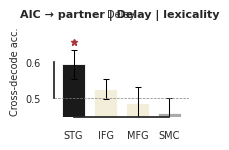

saved grantfig/aim3_3_articulator_cross_roi_delay.svg


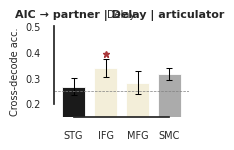

In [40]:
lex_cross = load_cross_roi_window('LexicalDelay', 'lexicality')
plot_cross_roi_delay_bars(
    lex_cross, 'lexicality',
    'AIC → partner | Delay | lexicality',
    save_path=GRANTFIG_DIR / 'aim3_3_lexicality_cross_roi_delay.svg',
)
plt.show()

art_cross = load_cross_roi_window('PhonemeSequence', 'articulator')
plot_cross_roi_delay_bars(
    art_cross, 'articulator',
    'AIC → partner | Delay | articulator',
    save_path=GRANTFIG_DIR / 'aim3_3_articulator_cross_roi_delay.svg',
)
plt.show()

saved grantfig/aim3_explore_AIC_partner_count.svg
saved grantfig/aim3_explore_AIC_brain_allphases.svg | focus=68 partner=166


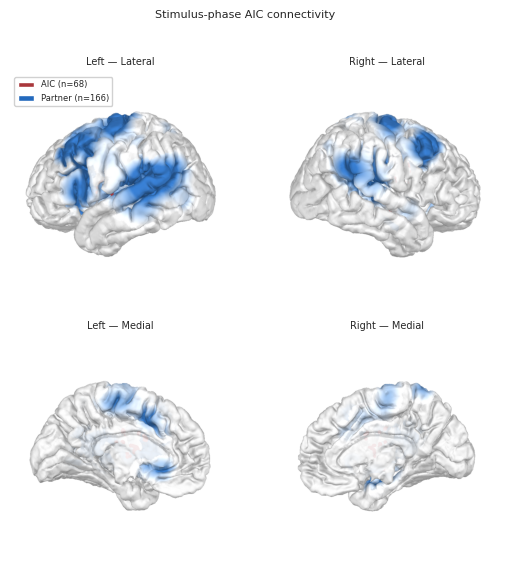

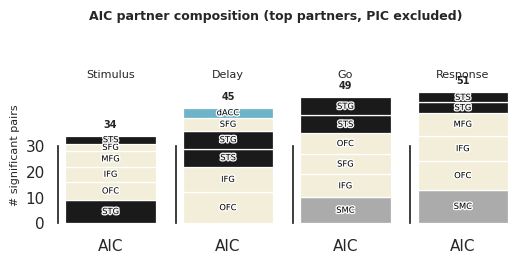

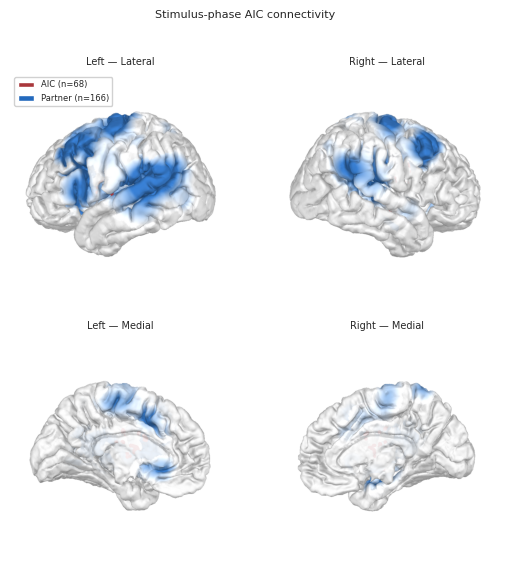

In [28]:
plot_partner_count_bar(
    peaks_df, focus_rois=['AIC'], top_k=6,
    savepath=GRANTFIG_DIR / 'aim3_explore_AIC_partner_count.svg',
)

plot_connectivity_brain(
    sig_roi_df, HGAs, phases=PHASES, focus_roi='AIC',
    savepath=GRANTFIG_DIR / 'aim3_explore_AIC_brain_allphases.svg',
)

# Per-phase brain maps (explore):
# for phase in ['stimulus', 'delay', 'go', 'response']:
#     plot_connectivity_brain(
#         sig_roi_df, HGAs, phase, focus_roi='AIC',
#         savepath=GRANTFIG_DIR / f'aim3_explore_AIC_brain_{phase}.svg',
#     )
